In [2]:
import time
import matplotlib.pyplot as plt
import numpy as np
from fenics import *
from dolfin import *
from mshr import *

# Problem statement

$$\frac{\partial T}{\partial t} - \sigma \Delta T=0\ in\ V, $$
$$T(x;y;z;0)=T_0\ in\ V, $$
$$T(x;y;z;t)=T_R\ on\ Г,$$
$T_0=5^\circ C,\ T_R=25^\circ C.$ 

# Backward Euler application

$$\frac{u^{n+1}-u^n}{\tau}-\sigma\Delta u^{n+1} = 0\,\in V$$
$$u^{n+1}-u^n = \sigma\tau\Delta u^{n+1}$$
Consider $u^n$ to be fixed and known, denote $u^{n+1} = u$. Then
$$u - \sigma\tau\nabla\cdot\nabla u = u^n$$
To derive the weak form, we need to multiply the equation by a test function v $\in L_2(V)$ such that $\nabla v \in L_2(V)$ and $v=0$ on Г
$$\int_\Omega uv - \sigma\tau\int_\Omega \nabla\cdot\nabla u v = \int_\Omega u^n v $$
$$\int_\Omega \nabla\cdot(\nabla u v) = \int_\Omega \nabla\cdot\nabla u v + \int_\Omega \nabla u \cdot \nabla v = \int_\Gamma \nabla u v = 0$$ because v on Г is equal to 0. Therefore,
$$\int_\Omega uv + \sigma\tau\int_\Omega \nabla u \cdot \nabla v = \int_\Omega u^n v$$
$$\int_\Omega (uv+\sigma\tau\nabla u\cdot\nabla v) = \int_\Omega u^nv$$

Generating mesh with CGAL 3D mesh generator


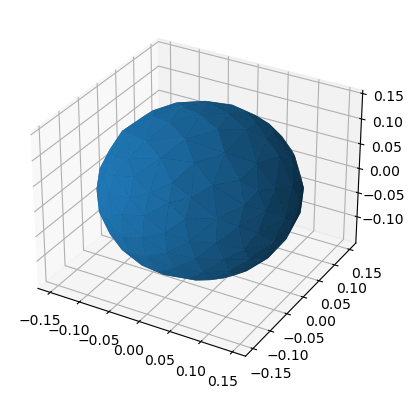

In [3]:
melon = Sphere(Point(0,0,0), 0.15)
mesh = generate_mesh(melon, 8)
plot(mesh)

In [3]:
# how to find out the number of cells, vertices - if you need that
mesh.num_cells(), mesh.num_vertices()

(1184, 286)

## Applying P1 finite element discretization

In [126]:
tau = 60
sigma = 0.15*1e-6
T0 = 278
T_bc = 298
Tm = 288

In [127]:
V1 = FunctionSpace(mesh, 'P', 1)

In [128]:
execution_time1 = []

mean_temp_array1 = []
time_array1 = [0]

for i in range(10):
    u1 = TrialFunction(V1)
    v1 = TestFunction(V1)
    u_p1 = Function(V1)
    u_p1.interpolate(Constant(T0))
    a1 = (u1 * v1 + sigma * tau * dot(grad(u1), grad(v1))) * dx
    L1 = v1 * u_p1 * dx

    bc1 = DirichletBC(V1, Constant(T_bc), "on_boundary")

    marker1 = Function(V1)
    marker1.interpolate(Constant(1))

    mean_temp = assemble(u_p1 * dx) / assemble(marker1 * dx)

    t = 0
    u = Function(V1)
    # times = [0]

    if i == 0:
        mean_temp_array1.append(mean_temp)
    
    t0 = time.perf_counter()
    while mean_temp < Tm:
        solve(a1 == L1, u, bc1)
        mean_temp = assemble(u * dx) / assemble(marker1 * dx) # mean temperature
        u_p1.assign(u)
        t += tau
        if i == 0:
            mean_temp_array1.append(mean_temp)
            time_array1.append(t)
    execution_time1.append(time.perf_counter()-t0)

Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational p

In [56]:
# mean time of the execution of the program using P1 discretization
np.mean(execution_time1) 

0.9679789376999451

## Applying P2 finite element discretization

In [133]:
V2 = FunctionSpace(mesh, 'P', 2)

In [134]:
execution_time2 = []

mean_temp_array2 = []
time_array2 = [0]

for i in range(10):
    u2 = TrialFunction(V2)
    v2 = TestFunction(V2)
    u_p2 = Function(V2)
    u_p2.interpolate(Constant(T0))
    a2 = (u2 * v2 + sigma * tau * dot(grad(u2), grad(v2))) * dx
    L2 = v2 * u_p2 * dx

    bc2 = DirichletBC(V2, Constant(T_bc), "on_boundary")

    marker2 = Function(V2)
    marker2.interpolate(Constant(1))

    mean_temp = assemble(u_p2 * dx) / assemble(marker2 * dx)

    t = 0
    u = Function(V2)

    if i == 0:
        mean_temp_array2.append(mean_temp)
    
    t0 = time.perf_counter()
    while mean_temp < Tm:
        solve(a2 == L2, u, bc2)
        mean_temp = assemble(u * dx) / assemble(marker2 * dx) # mean temperature
        u_p2.assign(u)
        t += tau
        if i == 0:
            mean_temp_array2.append(mean_temp)
            time_array2.append(t)
    execution_time2.append(time.perf_counter()-t0)
    

Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational p

In [129]:
# mean time of the execution of the program using P2 discretization
np.mean(execution_time2), np.mean(execution_time1) 

(6.4461829821000265, 1.1103909422996368)

As we see, the execution time is higher in case of using P2 functions rather then P1. It is due to higher computational effeciency when using P2 finite-element discretization.

## Comparison to analytical solution

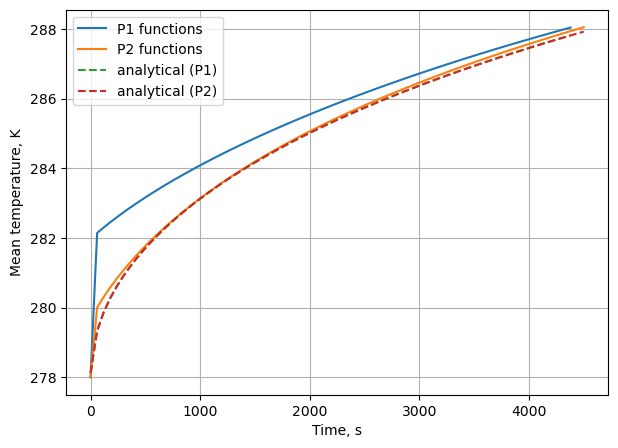

In [135]:
# tmean(t)
plt.figure(figsize = (7,5), dpi = 100)

analyt_sol1 = lambda x,n: 298+(278-298)*6/np.pi/np.pi*np.sum([1/i/i*np.exp(-sigma*np.pi*np.pi*i*i*x/.15/.15) for i in range(1,n)])
plt.plot(time_array1, mean_temp_array1, label = "P1 functions")
plt.plot(time_array2, mean_temp_array2, label = "P2 functions")
plt.plot(time_array1, [analyt_sol1(t, 100) for t in time_array1], '--', label = "analytical (P1)")
plt.plot(time_array2, [analyt_sol1(t, 100) for t in time_array2], '--', label = "analytical (P2)")

plt.grid()
plt.xlabel('Time, s')
plt.ylabel('Mean temperature, K')
plt.legend()

The solution obtained using P2 functions is more accurate (is closer to the analytical solution) because such basis functions are of 2 order.

# Preheted watermelon

In [77]:
u_p = Function(V1)
tau = 60
sigma = 0.15*1e-6
u_p.interpolate(Expression("x[0] <= 0+tolerance ? 273 : 283", tolerance = 1e-14, degree = 0))

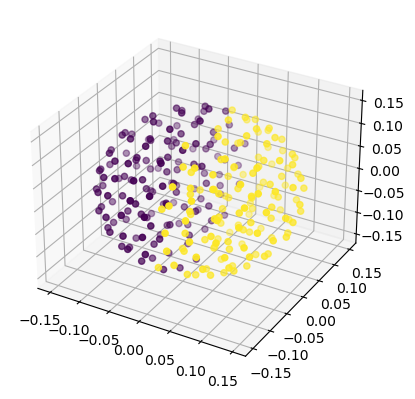

In [79]:
plot(u_p)

In [109]:
def make_line(u):
    x = np.linspace(-0.145, 0.145)
    y = 0
    z = 0
    u_ = []
    for x_ in x:
        u_.append(u(x_,y,z))
    return u_

## Backward Euler scheme

In [110]:
time_array1 = []
time_array2 = []
temp1 = []
temp2 = []

for V in [V1, V2]:
    u = TrialFunction(V)
    v = TestFunction(V)
    u_p = Function(V)
    u_p.interpolate(Expression("x[0] <= 0+tolerance ? 273 : 283", tolerance = 1e-14, degree = 0))
    a = (u * v + sigma * tau * dot(grad(u), grad(v))) * dx
    L = v * u_p * dx

    bc = DirichletBC(V, Constant(T_bc), "on_boundary")

    marker = Function(V)
    marker.interpolate(Constant(1))

    mean_temp = assemble(u_p * dx) / assemble(marker * dx)

    t = 0
    u = Function(V)
    
    while mean_temp < Tm:
        solve(a == L, u, bc)
        mean_temp = assemble(u * dx) / assemble(marker * dx) # mean temperature
        u_p.assign(u)
        t += tau
        if t % 100 == 0:
            if V == V1:
                time_array1.append(t)
                temp1.append(make_line(u))
            else:
                time_array2.append(t)
                temp2.append(make_line(u))

Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational p

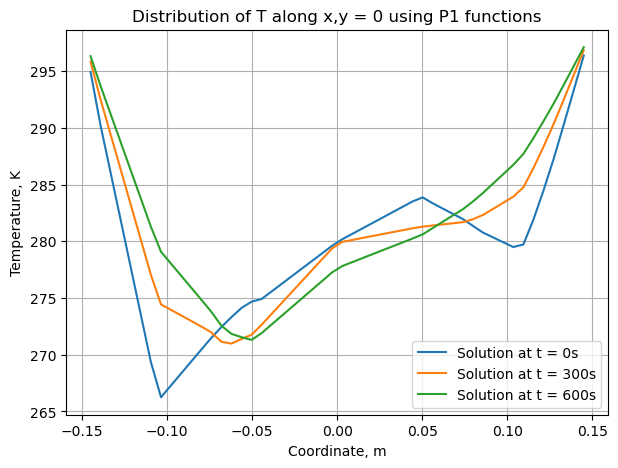

In [131]:
# P1 functions

plt.figure(figsize = (7,5), dpi = 100)

z = np.linspace(-0.145, 0.145)
plt.plot(z, temp1[0], label = f'Solution at t = {time_array1[0]}s')
plt.plot(z, temp1[5], label = f'Solution at t = {time_array1[5]}s')
plt.plot(z, temp1[10], label = f'Solution at t = {time_array1[10]}s')

plt.title('Distribution of T along x,y = 0 using P1 functions')
plt.xlabel('Coordinate, m')
plt.ylabel('Temperature, K')
plt.grid()
plt.legend()

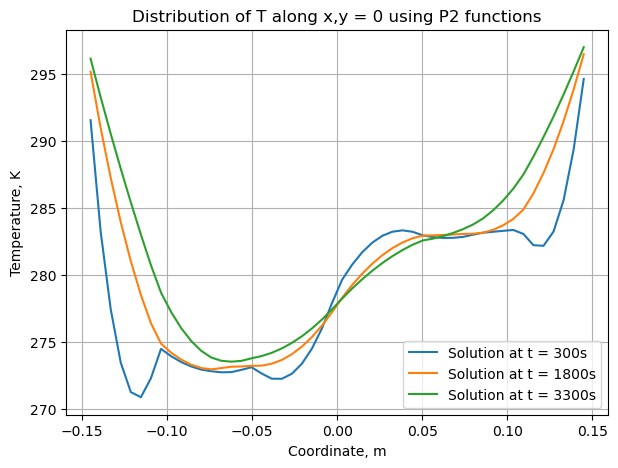

In [130]:
# P2 functions

plt.figure(figsize = (7,5), dpi = 100)

z = np.linspace(-0.145, 0.145)
plt.plot(z, temp2[0], label = f'Solution at t = {time_array2[0]}s')
plt.plot(z, temp2[5], label = f'Solution at t = {time_array2[5]}s')
plt.plot(z, temp2[10], label = f'Solution at t = {time_array2[10]}s')

plt.title('Distribution of T along x,y = 0 using P2 functions')
plt.xlabel('Coordinate, m')
plt.ylabel('Temperature, K')
plt.grid()
plt.legend()            

# Crank-Nicolson

$$\frac{u^{n+1}-u^n}{\tau}-0.5(\sigma\Delta u^{n+1}+\sigma\Delta u^{n}) = 0\,\in V$$
$$u^{n+1}-u^n = 0.5\sigma\tau\Delta u^{n+1}+0.5\sigma\tau\Delta u^{n}$$
Consider $u^n$ to be fixed and known, denote $u^{n+1} = u$. Then
$$u-u^n = 0.5\sigma\tau\Delta u+0.5\sigma\tau\Delta u^{n}$$
$$u-0.5\sigma\tau\Delta u = u^n+0.5\sigma\tau\Delta u^{n}$$
The weak form
$$\int_\Omega uv - 0.5\sigma\tau\int_\Omega \nabla\cdot\nabla u v = \int_\Omega (u^n+0.5\sigma\tau\Delta u^{n}) v $$
$$\int_\Omega uv + 0.5\sigma\tau\int_\Omega \nabla u \cdot \nabla v = \int_\Omega (u^n+0.5\sigma\tau\Delta u^{n}) v$$
$$\int_\Omega (uv+0.5\sigma\tau\nabla u\cdot\nabla v) = \int_\Omega (u^n+0.5\sigma\tau\Delta u^{n}) v$$

In [113]:
cn_time_array1 = []
cn_time_array2 = []
cn_temp1 = []
cn_temp2 = []

for V in [V1, V2]:
    u = TrialFunction(V)
    v = TestFunction(V)
    u_p = Function(V)
    u_p.interpolate(Expression("x[0] <= 0+tolerance ? 273 : 283", tolerance = 1e-14, degree = 0))
    a = (u*v+0.5*sigma*tau*dot(grad(u), grad(v)))*dx
    L = v*(u_p+0.5*sigma*tau*div(grad(u_p)))*dx
    
    bc = DirichletBC(V, Constant(T_bc), "on_boundary")

    marker = Function(V)
    marker.interpolate(Constant(1))

    mean_temp = assemble(u_p * dx) / assemble(marker * dx)

    t = 0
    u = Function(V)
    
    while mean_temp < Tm:
        solve(a == L, u, bc)
        mean_temp = assemble(u * dx) / assemble(marker * dx) # mean temperature
        u_p.assign(u)
        t += tau
        if t % 100 == 0:
            if V == V1:
                cn_time_array1.append(t)
                cn_temp1.append(make_line(u))
            else:
                cn_time_array2.append(t)
                cn_temp2.append(make_line(u))

Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational p

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Calling FFC just-in-time (JIT) compiler, this may take some time.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem

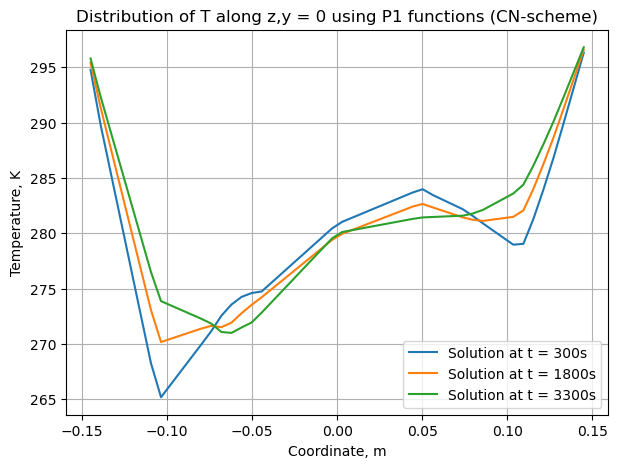

In [124]:
# P1 functions

plt.figure(figsize = (7,5), dpi = 100)

z = np.linspace(-0.145, 0.145)
plt.plot(z, cn_temp1[0], label = f'Solution at t = {cn_time_array1[0]}s')
plt.plot(z, cn_temp1[5], label = f'Solution at t = {cn_time_array1[5]}s')
plt.plot(z, cn_temp1[10], label = f'Solution at t = {cn_time_array1[10]}s')

plt.title('Distribution of T along z,y = 0 using P1 functions (CN-scheme)')
plt.xlabel('Coordinate, m')
plt.ylabel('Temperature, K')
plt.grid()
plt.legend()      

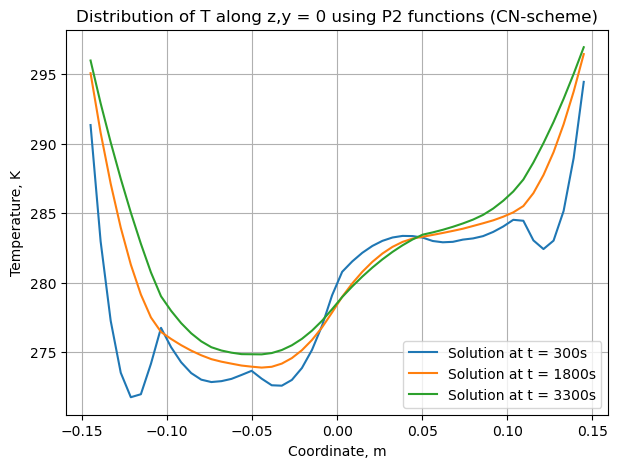

In [123]:
# P2 functions

plt.figure(figsize = (7,5), dpi = 100)

z = np.linspace(-0.145, 0.145)
plt.plot(z, cn_temp2[0], label = f'Solution at t = {cn_time_array2[0]}s')
plt.plot(z, cn_temp2[5], label = f'Solution at t = {cn_time_array2[5]}s')
plt.plot(z, cn_temp2[10], label = f'Solution at t = {cn_time_array2[10]}s')

plt.title('Distribution of T along z,y = 0 using P2 functions (CN-scheme)')
plt.xlabel('Coordinate, m')
plt.ylabel('Temperature, K')
plt.grid()
plt.legend()      

## Comparison of the 4 methods

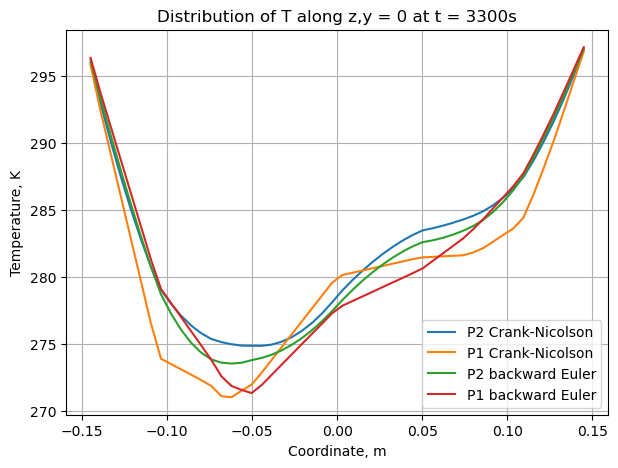

In [122]:
plt.figure(figsize = (7,5), dpi = 100)

z = np.linspace(-0.145, 0.145)
plt.plot(z, cn_temp2[10], label = f'P2 Crank-Nicolson')
plt.plot(z, cn_temp1[10], label = f'P1 Crank-Nicolson')
plt.plot(z, temp2[10], label = f'P2 backward Euler')
plt.plot(z, temp1[10], label = f'P1 backward Euler')

plt.title(f'Distribution of T along z,y = 0 at t = {cn_time_array2[10]}s')
plt.xlabel('Coordinate, m')
plt.ylabel('Temperature, K')
plt.grid()
plt.legend()   

If we'll compare the solution obtained using P2 Crank-Nicolson and P2 backward Euler discretizations, we'll notice that it is very similar to each other and probably to the real solution. P1 Crank-Nicolson and P1 backward Euler discretizations are less accurate, because P1 functions are only first order. Thus, the most accurate scheme is P2 Crank-Nicolson, because in comparison to P2 backward Eules discretization it is 2 order of approximation.